# Exp 1 vs Exp 2 comparison figures

Side-by-side versions of Figs 7a, 8a, 9a, 10a, 10b, 11a, 11d. Exp 1 = R1G_MFR, 20-1 condition only. Pairs: **Start ↔ Primacy, End ↔ Recency, Free ↔ Other**. Exp 1 bars are shaded lighter.

Plotting helpers live in `analyses/exp_compare.py`. Outputs go to `figures/*_exp1exp2.pdf`, plus a summary table at `figures/exp1exp2_summary.csv`.

**Requires** the R1G_MFR repo next to this one (`../R1G_MFR`). For Murdock (1962), unzip `Murd62.data.tgz` from the CML Data Archive into `data/murdock1962/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import analyses.spc as spc
import analyses.mwr as mwr
import analyses.r1_intrusion as r1_intrusion
import analyses.rt_init as rt_init
import analyses.pli_eli as pli_eli
import analyses.tcl as tcl
import analyses.scl as scl
import analyses.exp_compare as ec
import warnings; warnings.filterwarnings('ignore')
from data.spellcheck import spellcheck_recalls_dl
from data.prolific_quality import filter_sessions_by_quality, dedupe_replayed_sessions

# Switches
HARMONIZE_INTRUSIONS = True   # recompute Exp 1 PLI/ELI with the Exp 2 denominator (see exp_compare docstring)
ec.EXP1_DIR = Path('../R1G_MFR'); ec.EXP1_DF_DIR = ec.EXP1_DIR / 'analyses' / 'dataframes'

## 1. Exp 2: load and clean
Mirrors `analyses_new.ipynb` sections 0, 1 and *Correct Filtering (FINAL ALGO)*. If you change the pipeline there, change it here too.

In [2]:
data_dir = Path('data/data_storage')
data_path = max(data_dir.glob('dirfru_trials*.csv'), key=lambda p: p.stat().st_mtime)
raw = pd.read_csv(data_path, low_memory=False)
print(f'Loaded {data_path}')

exclude_pid = []
raw = raw[~raw['prolific_pid'].isin(exclude_pid)].copy()
raw = dedupe_replayed_sessions(raw)

df = raw[raw['type'].isin(['WORD', 'REC_WORD'])].copy()
for col in ['serial_position', 'list', 'session', 'l_length', 'rt']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

word_rows = df[df['type'] == 'WORD'].copy()
word_rows['word_key'] = word_rows['word'].str.lower().str.strip()
word_maps = word_rows.set_index(['prolific_pid', 'session', 'list', 'word_key'])['serial_position'].to_dict()

def recover_sp(row):
    if row['type'] != 'REC_WORD':
        return row['serial_position']
    if pd.isna(row['rec_word']) or str(row['rec_word']).strip() in ['', 'null']:
        return 99
    key = (row['prolific_pid'], row['session'], row['list'], str(row['rec_word']).lower().strip())
    return word_maps.get(key, 88)

# Response cleaning (filler, multi-word entries, annotation characters); see data/response_cleaning.py
from data.response_cleaning import clean_responses
df, cleaning_log, removed_responses = clean_responses(df)
print(cleaning_log)

df['serial_position'] = df.apply(recover_sp, axis=1)
df = spellcheck_recalls_dl(df)
df = filter_sessions_by_quality(df, raw)

df = df[df['study_id'].isin(['6a94e3286f8fd3491209112a', '6a94e406a70405ad5a421026', '6a94e5555b00e0e80a3ac706',
                             '6a94e598703277b3ace1b216', '6a94e5d410e6c6c4deca61c7'])]

p0 = set(df[df['session'] == 0]['prolific_pid']); p1 = set(df[df['session'] == 1]['prolific_pid']); p2 = set(df[df['session'] == 2]['prolific_pid'])
filtered_df = df[(df['prolific_pid'].isin(p0 & p1 & p2)) & (df['session'] >= 1)].copy()
filtered_df['initiation_condition'] = filtered_df['initiation_condition'].map({'primacy': 'start', 'recency': 'end', 'free': 'free'})
print(f"Participants included: {filtered_df['prolific_pid'].nunique()}")
print(filtered_df.drop_duplicates(['prolific_pid', 'initiation_condition']).groupby('initiation_condition')['prolific_pid'].nunique())

Loaded data/data_storage/dirfru_trials_20261005_152130.csv


Participant 69e2b2d707a51a46285ebc85 session 2: found 2 session_ids ['6ab5f62a17c1dcf29367bd20', '0sxjdfie4s1s']; keeping 6ab5f62a17c1dcf29367bd20 (489 rows), dropping ['0sxjdfie4s1s'].


{'filler_removed': 1460, 'filler_participants': 17, 'filler_max_from_one_participant': 1151, 'multiword_removed': 114, 'multiword_participants': 45, 'annotation_stripped': 134}


Damerau-Levenshtein spellcheck corrected 4150 recall(s).


Participant 6109b252880d6d711a5645b4 in session 1 had a recall proportion of 0.96, which is above the threshold.


...

Participant 69eb5d9fbfddb861d43a0d0f in session 4 took notes.


Participant 6a178e2e2b82ec7429f2353c in session 3 had 2 trials with zero correct recalls.


Participant 6aaad41d8d7a5723ab6e9ce7 in session 0 had a recall proportion of 0.96, which is above the threshold.


Participant stel01 in session 3 had 2 trials with zero correct recalls.


Participants included: 125
initiation_condition
end      43
free     40
start    42
Name: prolific_pid, dtype: int64


## 2. Exp 2 measures

In [3]:
spc_df = spc.spc_df(filtered_df)
mwr_df = mwr.mwr(filtered_df)
r1_df = r1_intrusion.r1_intrusion_df(filtered_df)
r1_split_df = ec.r1_intrusion_split(filtered_df)         # first-recall PLI / ELI
rt_trials_df = rt_init.rt_init_trial_df(filtered_df)
rt_init_df = rt_init.rt_init_df(filtered_df)
plieli_df = pli_eli.intrusion_rates(filtered_df)
tcl_df = tcl.tcl(filtered_df)
wordpool = list(np.loadtxt('data/wordpool/wordpool_ltpFR3.txt', dtype=str))
w2v_scores = np.loadtxt('data/wordpool/w2v_scores_ltpFR3.txt')
scl_df = scl.scl(filtered_df, wordpool, w2v_scores)

## 3. Exp 1 (20-1) measures

In [4]:
exp1_spc = ec.load_exp1_spc()
exp1_mwr = ec.load_exp1('mwr_data_bsa.csv', ['mwr'])
exp1_r1  = ec.load_exp1('r1_intr_data_bsa.csv', ['prop_wrong'])
exp1_r1_split = ec.exp1_r1_split_from_events()        # first-recall PLI / ELI
exp1_rt_trials, exp1_rt = ec.load_exp1_rti()
exp1_tcl = ec.load_exp1('tcl_data_bsa.csv', ['tcl'])
exp1_scl = ec.load_exp1('scl_data_bsa.csv', ['scl'])

if HARMONIZE_INTRUSIONS:
    exp1_intr = ec.exp1_intrusions_from_events()          # columns pli, eli
    pli_col, eli_col = 'pli', 'eli'
else:
    exp1_intr = ec.load_exp1('intr_data_only_cr_bsa.csv', ['pli_rate', 'eli_rate'])  # as published in Exp 1 Fig 5
    pli_col, eli_col = 'pli_rate', 'eli_rate'

murdock = ec.load_murdock_spc('data/murdock1962', 20, 1)
if murdock is None:
    print('WARNING: Murdock (1962) data not found in data/murdock1962/. Fig 7a will omit it.')

Murdock (1962) 20-1: 1200 trials from data/murdock1962/Murd62.data/Murd62/fr20-1.txt


## 4. Figures

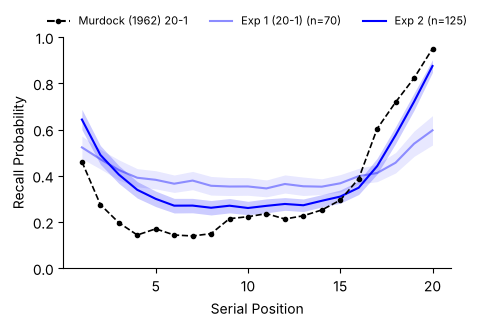

In [5]:
ec.plot_spc_overall_compare(spc_df, exp1_spc, murdock, path='figures/7a_spc_overall_exp1exp2.pdf')

### SPC statistics
Bootstrap RMSD of each Exp 2 group's mean SPC to Murdock (1962) 20-1 and Exp 1 20-1, then Welch tests of primacy (SP 1-5) and recency (SP 16-20) vs Exp 1.

In [ ]:
murd_rmsd, murd_rmsd_pairs = ec.bootstrap_spc_distance(spc_df, murdock)
display(murd_rmsd.round(3), murd_rmsd_pairs.round(4))

In [ ]:
exp1_rmsd, exp1_rmsd_pairs = ec.bootstrap_spc_distance(spc_df, exp1_spc)
display(exp1_rmsd.round(3), exp1_rmsd_pairs.round(4))

In [ ]:
ec.spc_window_welch(spc_df, exp1_spc).round(4)

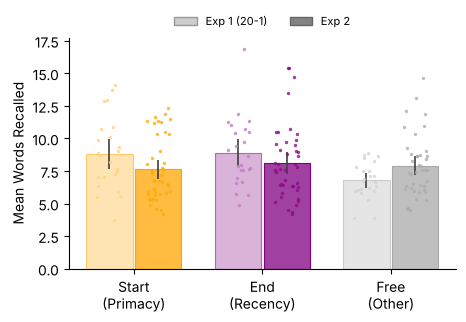

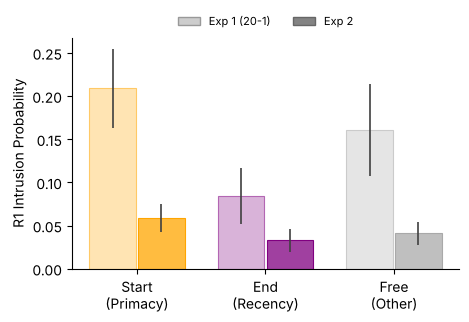

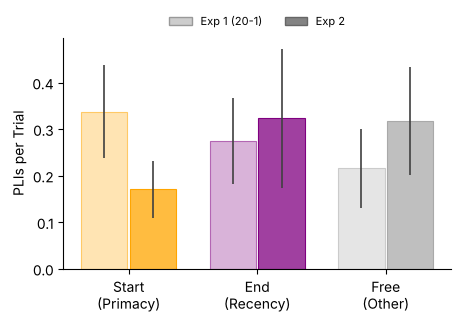

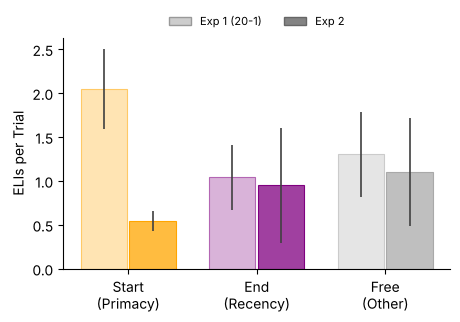

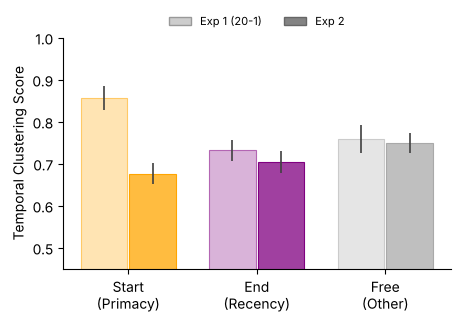

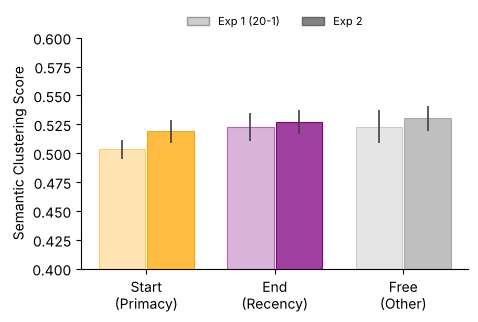

In [6]:
summaries = []
summaries.append(ec.plot_paired_bars(mwr_df, exp1_mwr, 'mwr', 'Mean Words Recalled', dots=True,
                                     path='figures/8a_mwr_by_condition_exp1exp2.pdf'))
summaries.append(ec.plot_r1_split(r1_split_df, exp1_r1_split,
                                  path='figures/9a_r1_intrusion_overall_exp1exp2.pdf'))
summaries.append(ec.plot_paired_bars(plieli_df, exp1_intr, 'pli', 'PLIs per Trial', exp1_y=pli_col,
                                     path='figures/10a_pli_exp1exp2.pdf'))
summaries.append(ec.plot_paired_bars(plieli_df, exp1_intr, 'eli', 'ELIs per Trial', exp1_y=eli_col,
                                     path='figures/10b_eli_exp1exp2.pdf'))
summaries.append(ec.plot_paired_bars(tcl_df, exp1_tcl, 'tcl', 'Temporal Clustering Score', ylim=(0.45, 1),
                                     path='figures/11a_tcl_overall_exp1exp2.pdf'))
summaries.append(ec.plot_paired_bars(scl_df, exp1_scl, 'scl', 'Semantic Clustering Score', ylim=(0.4, 0.6),
                                     path='figures/11d_scl_by_condition_exp1exp2.pdf'))

In [ ]:
ec.plot_rt_init_compare(rt_trials_df, rt_init_df, exp1_rt_trials, exp1_rt,
                        path='figures/9b_rt_init_exp1exp2.pdf')

## 5. Summary table (means, 95% CI half-widths, n)

In [7]:
summary = pd.concat(summaries, ignore_index=True)
summary.to_csv('figures/exp1exp2_summary.csv', index=False)
summary.round(3)

,measure,pair,experiment,mean,ci95,n
0,mwr,Start (Primacy),Exp 1 (20-1),8.828,1.138,23
1,mwr,Start (Primacy),Exp 2,7.647,0.734,42
2,mwr,End (Recency),Exp 1 (20-1),8.911,1.047,24
3,mwr,End (Recency),Exp 2,8.122,0.843,43
4,mwr,Free (Other),Exp 1 (20-1),6.782,0.565,23
5,mwr,Free (Other),Exp 2,7.900,0.732,40
6,prop_wrong,Start (Primacy),Exp 1 (20-1),0.209,0.046,23
7,prop_wrong,Start (Primacy),Exp 2,0.059,0.016,42
8,prop_wrong,End (Recency),Exp 1 (20-1),0.084,0.033,24
9,prop_wrong,End (Recency),Exp 2,0.033,0.013,43


## 6. PLI/ELI robustness check
Both definitions use the corrected denominator. `toggle=True` = only lists initiated with a correct recall (paper). `toggle=False` = all lists. Exp 1 statistics use a Python port of `strategy_anova.R` (reproduces the published R output exactly).

In [8]:
import analyses.intrusion_robustness as ir
Path('robustness').mkdir(exist_ok=True)

e1 = ir.exp1_intrusions()
pub = pd.read_csv(ec.EXP1_DF_DIR / 'intr_data_only_cr_bsa.csv')
exp1_tab = ir.exp1_strategy_table(e1, published=pub)
exp1_tab.to_csv('robustness/intrusions_exp1_anova.csv', index=False)
exp1_tab.round(4)

,definition,measure,strategy_F,strategy_p,strategy_eta_p_sq,strategy_x_ll_p,strategy_x_pr_p
0,True,pli,0.8049,0.4478,0.0037,0.4048,0.9762
1,True,eli,0.3410,0.7113,0.0016,0.7223,0.6132
2,False,pli,0.8342,0.4349,0.0038,0.3311,0.9340
3,False,eli,0.6136,0.5419,0.0028,0.8118,0.6045
4,published,pli,0.9454,0.3893,0.0043,0.3070,0.9946
5,published,eli,0.2104,0.8104,0.0010,0.3206,0.4102


In [9]:
exp2_tab = ir.exp2_contrasts(filtered_df)
exp2_tab.to_csv('robustness/intrusions_exp2_contrasts.csv', index=False)
exp2_tab[['toggle', 'measure', 'contrast', 'n_1', 'n_2', 't_stat', 'p_val', 'p_val_holm', 'cohen_d']].round(4)

,toggle,measure,contrast,n_1,n_2,t_stat,p_val,p_val_holm,cohen_d
0,True,pli,start vs free,42,40,-2.1845,0.0329,0.1972,-0.4892
1,True,pli,end vs free,43,40,0.0700,0.9443,1.0000,0.0152
2,True,pli,start vs end,42,43,-1.8558,0.0688,0.3438,-0.3992
3,True,eli,start vs free,42,40,-1.7362,0.0899,0.3597,-0.3925
4,True,eli,end vs free,43,40,-0.3213,0.7488,1.0000,-0.0703
5,True,eli,start vs end,42,43,-1.2030,0.2353,0.7060,-0.2581
6,False,pli,start vs free,42,40,-2.0306,0.0468,0.2806,-0.4547
7,False,pli,end vs free,43,40,0.0837,0.9335,1.0000,0.0182
8,False,pli,start vs end,42,43,-1.7569,0.0844,0.4220,-0.3779
9,False,eli,start vs free,42,40,-1.6576,0.1048,0.4220,-0.3746
